# 03 · ANN Model and Final 4-Model Comparison

The ANN architecture, loss, optimizer and callbacks are taken from `main.ipynb`. Changes for a fair, leakage-safe comparison:

* Trained and evaluated on the **same chronological train / validation / test split** from `01_EDA.ipynb`.
* **Early stopping and LR scheduling use the validation year (2013)**. `main.ipynb` used the test set.
* Preprocessor fit on the training split only.
* Trained only on rows with a measured target; scored on measured hours only.

*Run `01_EDA.ipynb` and `02_Baseline_Models.ipynb` first. The last section needs the baseline predictions.*

## 1. Setup and load the saved splits

In [11]:
import json, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import tensorflow as tf
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
import joblib

import warnings
warnings.filterwarnings('ignore')
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

DATA_DIR, RES_DIR = 'data', 'results'
os.makedirs(RES_DIR, exist_ok=True)

meta  = json.load(open(f'{DATA_DIR}/meta.json'))
TARGET, num_cols, cat_cols = meta['target'], meta['numerical_cols'], meta['categorical_cols']

train = pd.read_csv(f'{DATA_DIR}/train.csv', parse_dates=['datetime'])
val   = pd.read_csv(f'{DATA_DIR}/val.csv',   parse_dates=['datetime'])
test  = pd.read_csv(f'{DATA_DIR}/test.csv',  parse_dates=['datetime'])

# Same scored subsets as the baseline notebook (target actually measured)
tr, va, te = (d[d['target_observed']].reset_index(drop=True) for d in (train, val, test))
print(f'Scored rows -> train {len(tr)}, val {len(va)}, test {len(te)}')

Scored rows -> train 24394, val 8678, test 8661


## 2. Preprocessing (fit on train only) and log-transformed target

In [12]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([('scaler', RobustScaler())]), num_cols),
    ('cat', Pipeline([('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))]), cat_cols),
])
X_train = preprocessor.fit_transform(tr)    # fit on TRAIN only
X_val   = preprocessor.transform(va)
X_test  = preprocessor.transform(te)

y_train, y_val = np.log1p(tr[TARGET].values), np.log1p(va[TARGET].values)
y_test_raw = te[TARGET].values

print('Processed shapes:', X_train.shape, X_val.shape, X_test.shape)

Processed shapes: (24394, 33) (8678, 33) (8661, 33)


## 3. Model architecture (from `main.ipynb`)

In [13]:
model = Sequential([
    Input(shape=(X_train.shape[1],)),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),

    Dense(1, activation='linear'),
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 256)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,889 (210.50 KB)

 Trainable params: 52,929 (206.75 KB)

 Non-trainable params: 960 (3.75 KB)

## 4. Compile and train (early stopping on the validation year)

In [14]:
model.compile(optimizer=Adam(learning_rate=0.001), loss=tf.keras.losses.Huber(), metrics=['mae'])

callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),      # <- validation year, NOT the test set
    epochs=200,
    batch_size=128,
    callbacks=callbacks,
    shuffle=True,                        # shuffling rows inside the training set is fine; the split itself is chronological
    verbose=1,
)

Epoch 1/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 2.5542 - mae: 3.0416 - val_loss: 0.6673 - val_mae: 1.1094 - learning_rate: 0.0010
Epoch 2/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.4096 - mae: 0.7533 - val_loss: 0.0685 - val_mae: 0.2749 - learning_rate: 0.0010
Epoch 3/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2618 - mae: 0.5660 - val_loss: 0.0611 - val_mae: 0.2563 - learning_rate: 0.0010
Epoch 4/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2157 - mae: 0.5035 - val_loss: 0.0592 - val_mae: 0.2445 - learning_rate: 0.0010
Epoch 5/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1872 - mae: 0.4628 - val_loss: 0.0573 - val_mae: 0.2563 - learning_rate: 0.0010
Epoch 6/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1642 - mae: 0.4304 - val_loss: 0.0538 - val_mae: 0.2363 - learning_rate: 0.0010
Epoch 7/200
191/191 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1466 - mae: 0.4035 - val_loss: 0.0467 - val_mae: 0.2244 - learning_rate: 0.0010

## 5. Loss curves

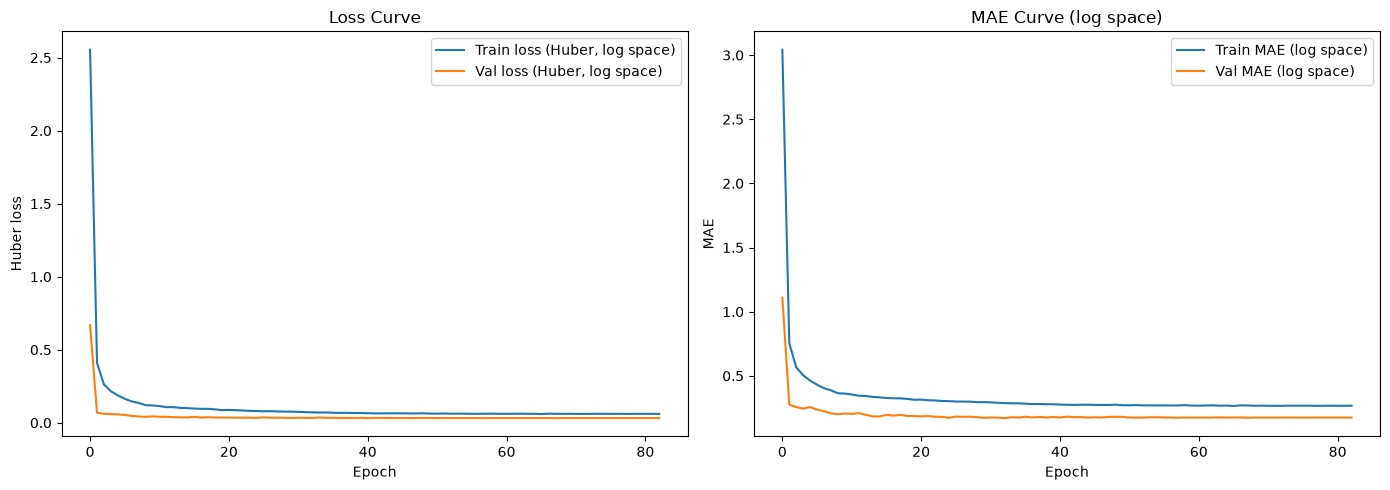

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train loss (Huber, log space)')
axes[0].plot(history.history['val_loss'], label='Val loss (Huber, log space)')
axes[0].set_title('Loss Curve'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Huber loss'); axes[0].legend()

axes[1].plot(history.history['mae'],     label='Train MAE (log space)')
axes[1].plot(history.history['val_mae'], label='Val MAE (log space)')
axes[1].set_title('MAE Curve (log space)'); axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE'); axes[1].legend()
plt.tight_layout(); plt.show()

## 6. ANN evaluation (raw µg/m³)

In [16]:
def metrics(y_true, y_pred):
    return {'MAE':  mean_absolute_error(y_true, y_pred),
            'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'R2':   r2_score(y_true, y_pred)}

def ann_predict(X):
    return np.maximum(np.expm1(model.predict(X, verbose=0).flatten()), 0)

ann_val, ann_test = ann_predict(X_val), ann_predict(X_test)
m_val, m_test = metrics(va[TARGET].values, ann_val), metrics(y_test_raw, ann_test)

print('ANN — VALIDATION (2013):', {k: round(v, 4) for k, v in m_val.items()})
print('ANN — TEST (2014):      ', {k: round(v, 4) for k, v in m_test.items()})

ANN — VALIDATION (2013): {'MAE': 14.4212, 'RMSE': 26.3144, 'R2': 0.928}
ANN — TEST (2014):       {'MAE': 12.9392, 'RMSE': 22.4843, 'R2': 0.9422}


## 7. Residual analysis (test)

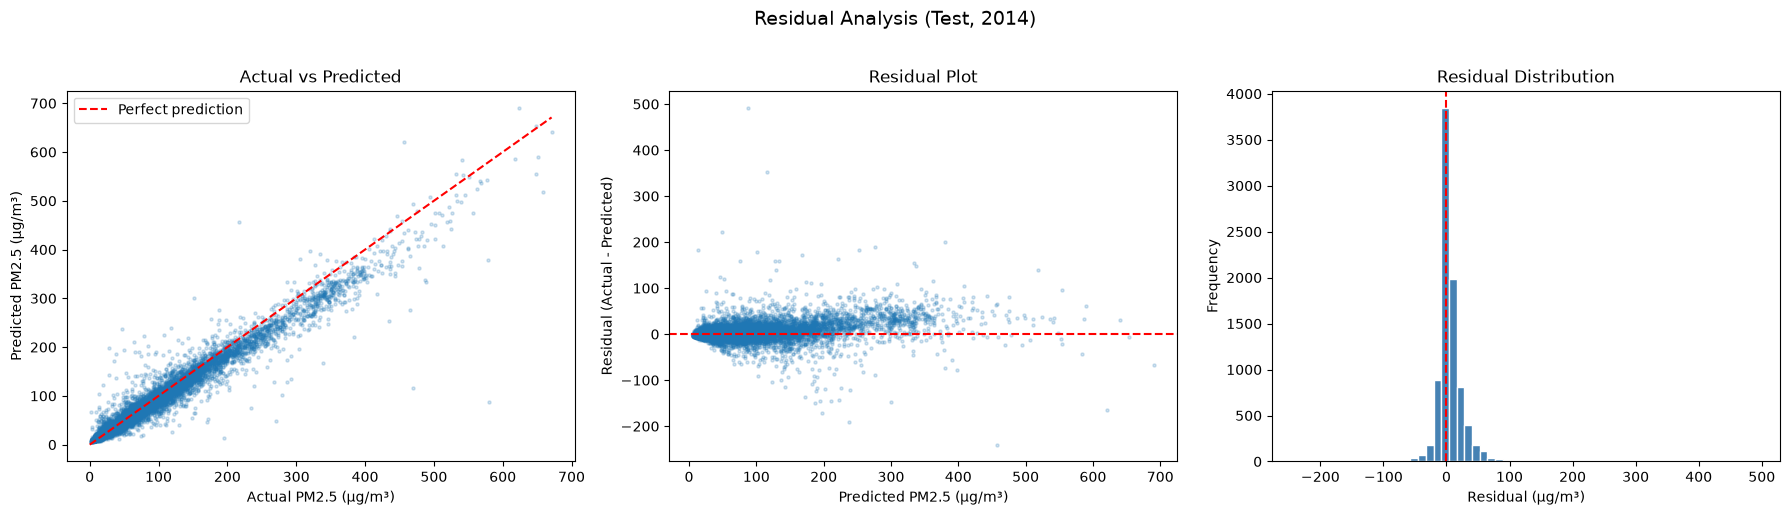

Mean residual: 4.85 µg/m³ (near 0 = unbiased)
Std  residual: 21.96 µg/m³


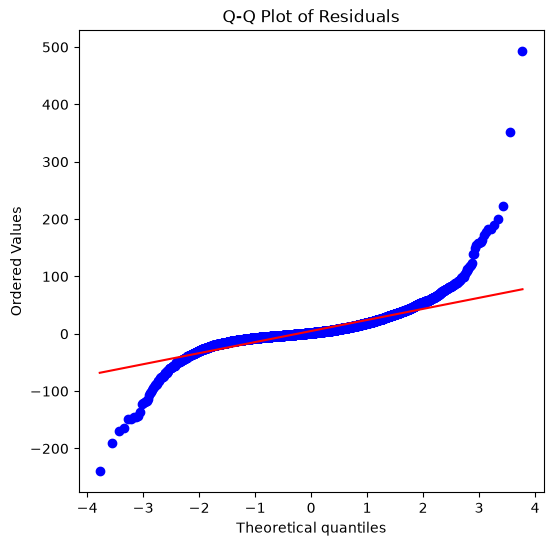

In [17]:
residuals = y_test_raw - ann_test
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].scatter(y_test_raw, ann_test, alpha=0.2, s=5)
axes[0].plot([0, y_test_raw.max()], [0, y_test_raw.max()], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual PM2.5 (µg/m³)'); axes[0].set_ylabel('Predicted PM2.5 (µg/m³)'); axes[0].set_title('Actual vs Predicted'); axes[0].legend()

axes[1].scatter(ann_test, residuals, alpha=0.2, s=5)
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_xlabel('Predicted PM2.5 (µg/m³)'); axes[1].set_ylabel('Residual (Actual - Predicted)'); axes[1].set_title('Residual Plot')

axes[2].hist(residuals, bins=60, color='steelblue', edgecolor='white')
axes[2].axvline(0, color='red', linestyle='--')
axes[2].set_xlabel('Residual (µg/m³)'); axes[2].set_ylabel('Frequency'); axes[2].set_title('Residual Distribution')

plt.suptitle('Residual Analysis (Test, 2014)', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()

print(f'Mean residual: {residuals.mean():.2f} µg/m³ (near 0 = unbiased)')
print(f'Std  residual: {residuals.std():.2f} µg/m³')

plt.figure(figsize=(6, 6))
stats.probplot(residuals, dist='norm', plot=plt)
plt.title('Q-Q Plot of Residuals'); plt.show()

## 8. Save model, preprocessor and predictions

In [18]:
model.save(f'{RES_DIR}/pm25_ann_model.keras')
joblib.dump(preprocessor, f'{RES_DIR}/preprocessor.pkl')

pd.DataFrame({'datetime': te['datetime'], 'y_true': y_test_raw, 'ANN': ann_test}) \
  .to_csv(f'{RES_DIR}/test_predictions_ann.csv', index=False)
pd.DataFrame([{'Model': 'ANN', 'Split': 'val',  **m_val}, {'Model': 'ANN', 'Split': 'test', **m_test}]) \
  .to_csv(f'{RES_DIR}/metrics_ann.csv', index=False)
print('Saved.')

Saved.


## 9. Final comparison — Persistence, Seasonal Naive (3 variants), XGBoost and ANN

All four models are scored on the same 2014 test hours, in raw µg/m³.

In [19]:
base_pred = pd.read_csv(f'{RES_DIR}/test_predictions_baselines.csv', parse_dates=['datetime'])
ann_pred  = pd.read_csv(f'{RES_DIR}/test_predictions_ann.csv',       parse_dates=['datetime'])

comp = base_pred.merge(ann_pred[['datetime', 'y_true', 'ANN']], on='datetime', suffixes=('', '_ann'))
assert len(comp) == len(base_pred) == len(ann_pred), 'models were not scored on identical rows'
assert np.allclose(comp['y_true'], comp['y_true_ann']), 'ground truth differs between notebooks'

models = ['Persistence', 'Seasonal Naive (24h)', 'Seasonal Naive (level-adj.)', 'Seasonal Drift (fitted)', 'XGBoost', 'ANN']
table = pd.DataFrame({m: metrics(comp['y_true'], comp[m]) for m in models}).T
table['RMSE vs Persistence (%)'] = 100 * (table.loc['Persistence', 'RMSE'] - table['RMSE']) / table.loc['Persistence', 'RMSE']
table = table.round(4)
print(f'Test set (2014): {len(comp)} hourly forecasts')
display(table)
table.to_csv(f'{RES_DIR}/final_comparison_test.csv')

Test set (2014): 8661 hourly forecasts


,MAE,RMSE,R2,RMSE vs Persistence (%)
Persistence,11.9590,22.1365,0.9440,0.0000
Seasonal Naive (24h),67.6714,99.5022,-0.1319,-349.4949
Seasonal Naive (level-adj.),16.9926,28.3615,0.9080,-28.1211
Seasonal Drift (fitted),11.9552,22.1218,0.9441,0.0664
XGBoost,12.1311,23.1141,0.9389,-4.4164
ANN,12.9392,22.4843,0.9422,-1.5711


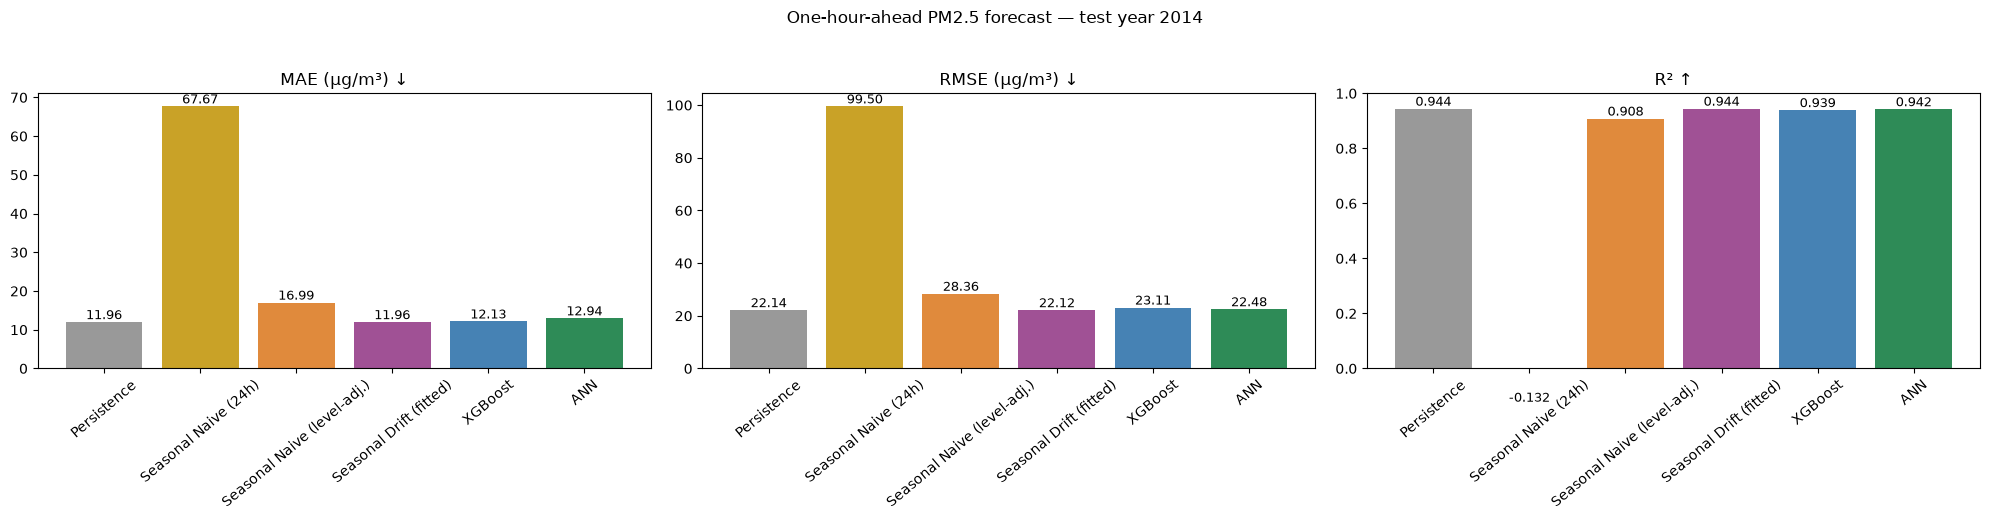

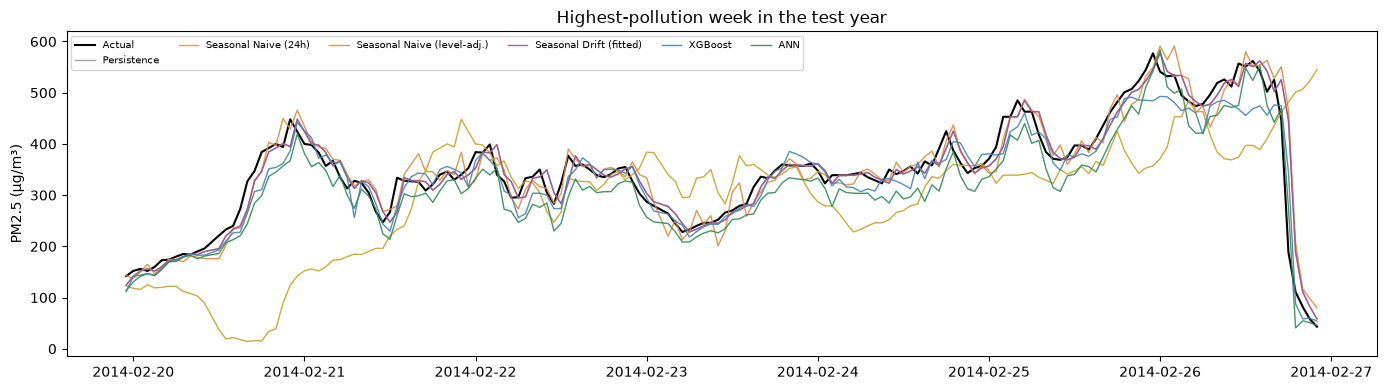

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
colors = ['#999999', '#c9a227', '#e08a3c', '#a05195', 'steelblue', 'seagreen']
for ax, col, title in zip(axes, ['MAE', 'RMSE', 'R2'], ['MAE (µg/m³) ↓', 'RMSE (µg/m³) ↓', 'R² ↑']):
    ax.bar(table.index, table[col], color=colors)
    ax.set_title(title); ax.tick_params(axis='x', rotation=40)
    for i, v in enumerate(table[col]):
        ax.text(i, v, f'{v:.2f}' if col != 'R2' else f'{v:.3f}', ha='center', va='bottom', fontsize=9)
axes[2].set_ylim(max(0, table['R2'].min() - 0.05), 1.0)
plt.suptitle('One-hour-ahead PM2.5 forecast — test year 2014', y=1.03)
plt.tight_layout(); plt.show()

# One high-pollution week for a visual comparison
week = comp.set_index('datetime')['y_true'].rolling(168).mean().idxmax()
w = comp[(comp.datetime > week - pd.Timedelta(days=7)) & (comp.datetime <= week)]
plt.figure(figsize=(14, 4))
plt.plot(w.datetime, w.y_true, 'k', lw=1.5, label='Actual')
for m, c in zip(models, colors):
    plt.plot(w.datetime, w[m], lw=1, color=c, label=m, alpha=0.9)
plt.ylabel('PM2.5 (µg/m³)'); plt.title('Highest-pollution week in the test year'); plt.legend(ncol=6, fontsize=7)
plt.tight_layout(); plt.show()